In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def numerov_step(psi_n, psi_nm1, k_n, k_nm1, k_np1, dx):
    # Un paso del método de Numerov
    factor = (2 * (1 - (5/12) * dx**2 * k_n) * psi_n - (1 + (1/12) * dx**2 * k_nm1) * psi_nm1) \
             / (1 + (1/12) * dx**2 * k_np1)
    return factor

def numerov_solve(E, x, dx, m, hbar):
    """Resuelve la ecuación de Schrödinger con el método de Numerov para energía E"""
    N = len(x)
    psi = np.zeros(N)

    # Definimos k^2 para el pozo infinito (V = 0 dentro del pozo)
    k2 = (2 * m * E / hbar**2) * np.ones(N)

    # Condiciones iniciales
    psi[0] = 0  # Condición de frontera en x=0
    psi[1] = dx  # Pequeño valor arbitrario para iniciar

    for i in range(1, N-1):
        psi[i+1] = numerov_step(psi[i], psi[i-1], k2[i], k2[i-1], k2[i+1], dx)

    return psi

# Parámetros del problema
L = 1e-9  # Longitud del pozo en metros (1 nm)
N = 1000  # Número de puntos
x = np.linspace(0, L, N)
dx = x[1] - x[0]

# Constantes físicas
m_e = 9.109e-31  # Masa del electrón en kg
hbar = 1.055e-34  # Constante de Planck reducida en J·s

def plot_wavefunction(n):
    """Grafica la función de onda para el nivel de energía n con el pozo de potencial"""
    E_n = (n**2 * np.pi**2 * hbar**2) / (2 * m_e * L**2)
    psi = numerov_solve(E_n, x, dx, m_e, hbar)
    psi /= np.max(np.abs(psi))  # Normalizar

    plt.figure(figsize=(8, 5))
    plt.plot(x, psi, label=f'n = {n}, E = {E_n:.2e} J')

   # Dibujar el pozo de potencial como una línea roja gruesa en los bordes
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Pared del pozo')
    plt.axvline(L, color='red', linestyle='--', linewidth=2)

    # Línea horizontal en y = 0 dentro del rango [0, L]
    plt.plot([0, L], [0, 0], color='red', linestyle='--', linewidth=2)

    plt.xlabel('x (m)')
    plt.ylabel('ψ(x)')
    plt.title('Solución de la ecuación de Schrödinger con Numerov para un electrón')
    plt.legend()
    plt.grid()
    plt.show()

# Crear widget para seleccionar el nivel de energía
n_slider = widgets.IntSlider(min=1, max=10, step=1, value=1, description='Nivel n:')
widgets.interactive(plot_wavefunction, n=n_slider)

interactive(children=(IntSlider(value=1, description='Nivel n:', max=10, min=1), Output()), _dom_classes=('wid…

<>:89: SyntaxWarning: invalid escape sequence '\p'
<>:89: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2899/345449788.py:89: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi(x)$')


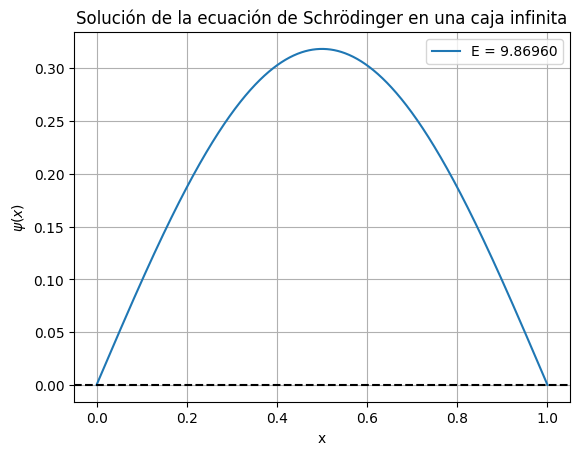

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def numerov_step(psi_prev, psi_curr, k_prev, k_curr, k_next, dx):
    """
    Realiza un solo paso del método de Numerov para integrar ecuaciones diferenciales.

    Argumentos:
    - psi_prev: valor de psi en el punto i-1
    - psi_curr: valor de psi en el punto i
    - k_prev, k_curr, k_next: valores de k^2 en i-1, i y i+1
    - dx: paso entre puntos

    Retorna:
    - psi_next: valor de psi en el punto i+1
    """
    # Fórmula del método de Numerov
    numerador = 2 * (1 - (5/12) * dx**2 * k_curr) * psi_curr
    numerador -= (1 + (1/12) * dx**2 * k_prev) * psi_prev
    denominador = 1 + (1/12) * dx**2 * k_next
    psi_next = numerador / denominador
    return psi_next

def solve_numerov(E, L=1.0, N=1000):
    """
    Resuelve numéricamente la ecuación de Schrödinger para una caja de potencial infinito.

    Argumentos:
    - E: energía tentativa
    - L: longitud de la caja
    - N: número de intervalos (resolución)

    Retorna:
    - x: arreglo de posiciones
    - psi: arreglo con la función de onda ψ(x)
    """
    dx = L / N                         # Paso de malla
    x = np.linspace(0, L, N+1)        # Puntos del dominio [0, L]

    # En unidades naturales (ħ²/2m = 1), k²(x) = E para V(x)=0
    k2 = np.full_like(x, E)

    # Condiciones iniciales
    psi = np.zeros_like(x)            # ψ(0) = 0
    psi[1] = 1e-3                     # Valor pequeño arbitrario en x=dx

    # Usamos el método de Numerov para integrar hacia la derecha
    for i in range(1, N):
        psi[i+1] = numerov_step(psi[i-1], psi[i], k2[i-1], k2[i], k2[i+1], dx)

    return x, psi

def energia_biseccion(E1, E2, tol=1e-5):
    """
    Encuentra un valor de energía E tal que ψ(L) = 0 usando el método de bisección.

    Argumentos:
    - E1, E2: extremos del intervalo inicial
    - tol: tolerancia para la convergencia

    Retorna:
    - E que cumple la condición de frontera en x = L
    """
    while abs(E2 - E1) > tol:
        E_mid = (E1 + E2) / 2
        _, psi_mid = solve_numerov(E_mid)
        psi_L_mid = psi_mid[-1]  # Valor de ψ en el borde derecho

        _, psi_E1 = solve_numerov(E1)
        psi_L_E1 = psi_E1[-1]

        # Si hay cambio de signo en ψ(L), hay un cero entre E1 y E_mid
        if psi_L_mid * psi_L_E1 < 0:
            E2 = E_mid
        else:
            E1 = E_mid

    return (E1 + E2) / 2

# Buscar un valor propio de energía entre 0.1 y 10
E_permitida = energia_biseccion(0.1, 10)

# Resolver la ecuación de Schrödinger para ese valor de energía
x, psi = solve_numerov(E_permitida)

plt.plot(x, psi, label=f'E = {E_permitida:.5f}')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('x')
plt.ylabel('$\psi(x)$')
plt.legend()
plt.title('Solución de la ecuación de Schrödinger en una caja infinita')
plt.grid()
plt.show()

<>:73: SyntaxWarning: invalid escape sequence '\p'
<>:73: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2899/2203719996.py:73: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi(x)$ y $V(x)$')


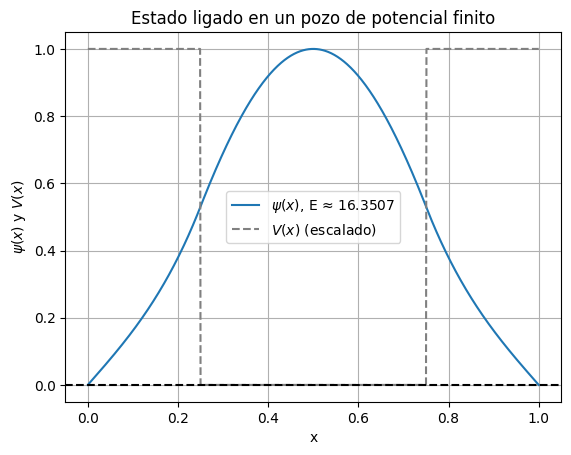

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def numerov_step(psi_prev, psi_curr, k_prev, k_curr, k_next, dx):
    """
    Un paso del método de Numerov para resolver ecuaciones diferenciales.
    """
    factor = (2 * (1 - (5/12) * dx**2 * k_curr) * psi_curr -
              (1 + (1/12) * dx**2 * k_prev) * psi_prev) / (1 + (1/12) * dx**2 * k_next)
    return factor

def potential_finite_well(x, L, a, V0):
    """
    Define un pozo de potencial finito centrado en L/2, de ancho a y profundidad V0.
    """
    center = L / 2
    return np.where(np.abs(x - center) <= a / 2, 0, V0)

def solve_numerov_finite_well(E, V0=50, a=0.5, L=1.0, N=1000):
    """
    Resuelve la ecuación de Schrödinger con método de Numerov para un pozo de potencial finito.
    """
    dx = L / N
    x = np.linspace(0, L, N+1)

    # Definir el potencial
    V = potential_finite_well(x, L, a, V0)

    # En unidades naturales: hbar^2 / 2m = 1 => k^2 = E - V(x)
    k2 = E - V

    # Condiciones iniciales
    psi = np.zeros_like(x)
    psi[1] = 1e-5  # pequeño valor inicial

    for i in range(1, N):
        psi[i+1] = numerov_step(psi[i-1], psi[i], k2[i-1], k2[i], k2[i+1], dx)

    return x, psi, V

def find_energy_bisection(E1, E2, V0=50, a=0.5, L=1.0, tol=1e-5):
    """
    Encuentra un valor propio de energía usando el método de bisección.
    """
    while abs(E2 - E1) > tol:
        E_mid = (E1 + E2) / 2
        _, psi_mid, _ = solve_numerov_finite_well(E_mid, V0=V0, a=a, L=L)

        if psi_mid[-1] * solve_numerov_finite_well(E1, V0=V0, a=a, L=L)[1][-1] < 0:
            E2 = E_mid
        else:
            E1 = E_mid

    return (E1 + E2) / 2

# Parámetros del pozo
L = 1.0     # longitud total del dominio
a = 0.5     # ancho del pozo
V0 = 50     # altura del potencial fuera del pozo

# Buscar energía propia (estado fundamental)
E_guess = find_energy_bisection(10, V0 - 25, V0=V0, a=a, L=L)
x, psi, V = solve_numerov_finite_well(E_guess, V0=V0, a=a, L=L)

# Normalizar psi para graficar
psi /= np.max(np.abs(psi))

# Graficar potencial y función de onda
plt.plot(x, psi, label=f'$\\psi(x)$, E ≈ {E_guess:.4f}')
plt.plot(x, V / np.max(V), '--', color='gray', label='$V(x)$ (escalado)')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('x')
plt.ylabel('$\psi(x)$ y $V(x)$')
plt.title('Estado ligado en un pozo de potencial finito')
plt.legend()
plt.grid(True)
plt.show()
